Saving ADANIPORTS_Last15Days_Classification.xlsx to ADANIPORTS_Last15Days_Classification (1).xlsx
Dataset Preview:
        Date    Open    High     Low   Close    Volume  %Deliverble  Target
0 2021-04-08  818.00  838.00  806.00  823.00  34025873       0.0675       1
1 2021-04-09  824.75  837.00  817.05  823.60  21804785       0.1088       0
2 2021-04-12  809.90  809.90  735.00  744.65  28112240       0.0944       0
3 2021-04-13  750.00  755.75  701.35  731.05  52812517       0.1692       1
4 2021-04-15  735.90  754.50  725.00  750.35  26108614       0.0670       1

Model Training Completed!


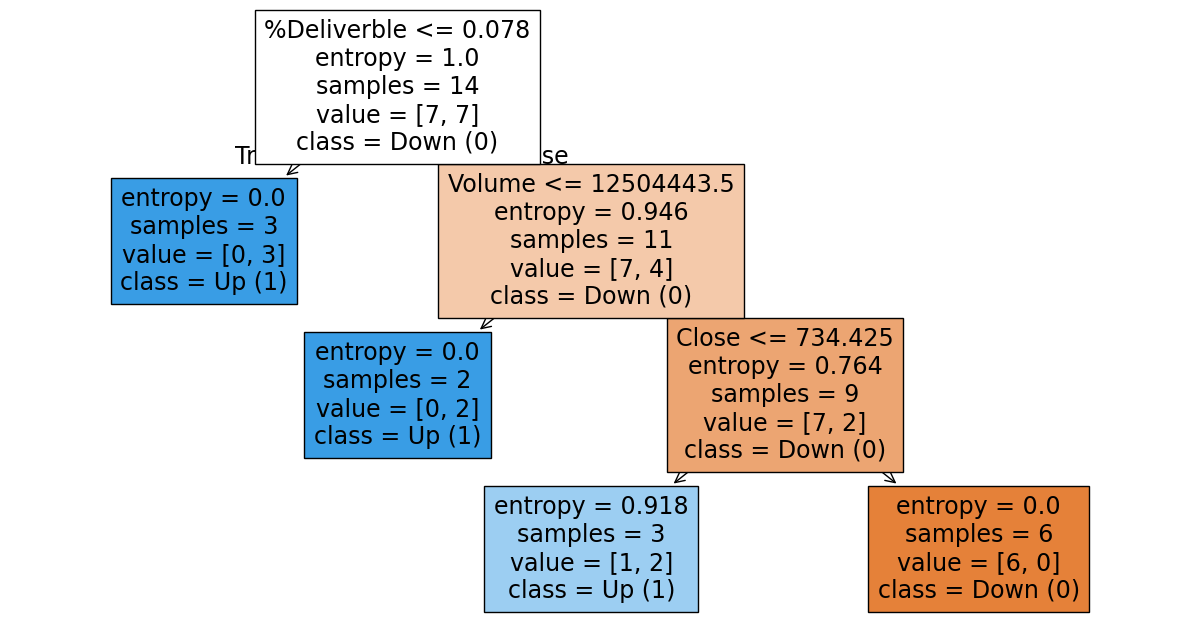


Enter 16th Day Market Data:
Open: 1554.70
High: 1559
Low: 1539
Close: 1554
Volume: 1359000
%Deliverble: 0.08

📈 Prediction: Market will go UP (1)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [3]:
# ==============================
# STEP 1: Import Libraries
# ==============================
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# ==============================
# STEP 2: Upload Dataset
# ==============================
from google.colab import files
uploaded = files.upload()

# Load the Excel file
df = pd.read_excel("ADANIPORTS_Last15Days_Classification.xlsx")

print("Dataset Preview:")
print(df.head())

# ==============================
# STEP 3: Define Features & Target
# ==============================
X = df[['Open', 'High', 'Low', 'Close', 'Volume', '%Deliverble']]
y = df['Target']

# ==============================
# STEP 4: Train Decision Tree
# ==============================
model = DecisionTreeClassifier(
    criterion='entropy',   # Using Information Gain (ID3 concept)
    max_depth=3,
    random_state=42
)

model.fit(X, y)

print("\nModel Training Completed!")

# ==============================
# STEP 5: Visualize Decision Tree
# ==============================
plt.figure(figsize=(15,8))
plot_tree(model,
          feature_names=X.columns,
          class_names=['Down (0)', 'Up (1)'],
          filled=True)
plt.show()

# ==============================
# STEP 6: Predict 16th Day
# ==============================
print("\nEnter 16th Day Market Data:")

open_price = float(input("Open: "))
high_price = float(input("High: "))
low_price = float(input("Low: "))
close_price = float(input("Close: "))
volume = float(input("Volume: "))
deliverable = float(input("%Deliverble: "))

new_day = np.array([[open_price, high_price, low_price, close_price, volume, deliverable]])

prediction = model.predict(new_day)

if prediction[0] == 1:
    print("\n📈 Prediction: Market will go UP (1)")
else:
    print("\n📉 Prediction: Market will go DOWN (0)")
